<a href="https://colab.research.google.com/github/dhans2007/ML_LAB/blob/main/ML_EXP_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DHANESH VC 24BAD018
EXPERIMENT-04

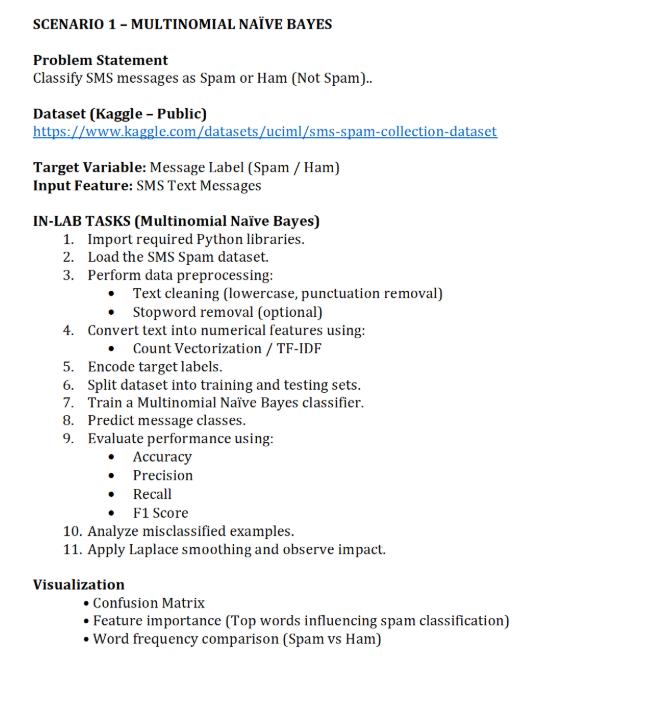

In [ ]:
#DHANESH VC 24BAD018
#Import libraries
import pandas as pd
import numpy as np
import string

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Model
from sklearn.naive_bayes import MultinomialNB

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
#load the dataset
df = pd.read_csv("spam.csv", encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
#Text cleaning
def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

df['message'] = df['message'].apply(clean_text)

In [ ]:
#Convert Text into Numerical Features
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['message'])

In [ ]:
#. Encode Target Labels
encoder = LabelEncoder()
y = pd.Series(encoder.fit_transform(df['label']))

In [ ]:
#train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Train multinomial naive bayes model
model = MultinomialNB()
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [ ]:
#Prediction
y_pred = model.predict(X_test)

In [ ]:
#Evalation metrices
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.97847533632287
Precision: 0.92
Recall: 0.92
F1 Score: 0.92


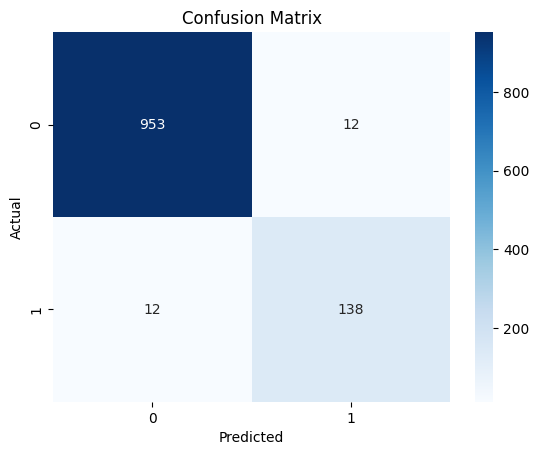

In [ ]:
#Confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#Feature importance
feature_names = vectorizer.get_feature_names_out()
log_probs = model.feature_log_prob_[1]   # Spam class

top10 = np.argsort(log_probs)[-10:]

for i in top10:
    print(feature_names[i])

is
now
or
the
for
free
your
you
call
to


In [ ]:
#Word frequency comparison
spam_words = df[df['label']=='spam']['message']
ham_words = df[df['label']=='ham']['message']

spam_vector = vectorizer.fit_transform(spam_words)
ham_vector = vectorizer.fit_transform(ham_words)

print("Top spam words:", spam_vector.sum(axis=0))
print("Top ham words:", ham_vector.sum(axis=0))

Top spam words: [[2 1 1 ... 1 1 1]]
Top ham words: [[1 9 1 ... 1 9 1]]


In [ ]:
#Misclassified examples
misclassified = df.iloc[y_test.index][y_test != y_pred]
print(misclassified.head())

     label                                            message
3245   ham  funny fact nobody teaches volcanoes 2 erupt ts...
3142   ham  boy i love u grl hogolo boy gold chain kodstin...
683   spam  hi im sue i am 20 years old and work as a lapd...
3504   ham              life alle moneeppolum oru pole allalo
4328   ham  1appledayno doctor 1tulsi leafdayno cancer 1le...


In [ ]:
#Laplace smoothing
model = MultinomialNB(alpha=0.1)
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0.1
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


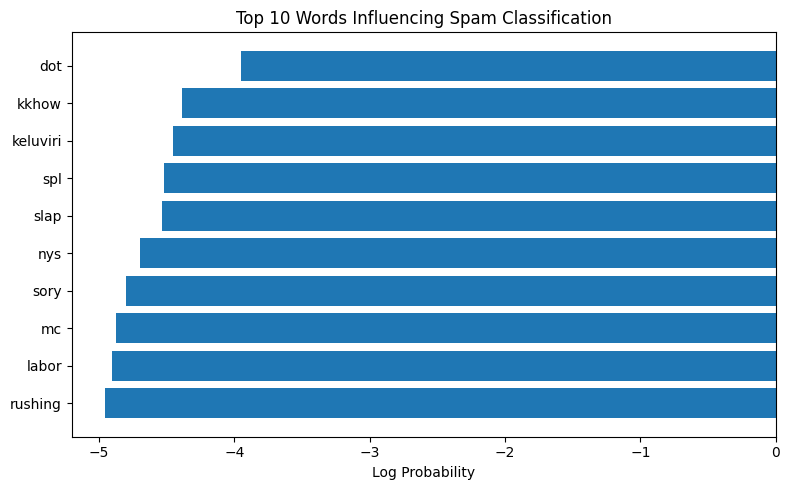

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

feature_names = vectorizer.get_feature_names_out()
spam_log_probs = model.feature_log_prob_[1]

min_len = min(len(feature_names), len(spam_log_probs))

feature_names = feature_names[:min_len]
spam_log_probs = spam_log_probs[:min_len]

top_indices = np.argsort(spam_log_probs)[-10:]
top_words = feature_names[top_indices]
top_values = spam_log_probs[top_indices]

plt.figure(figsize=(8,5))
plt.barh(top_words, top_values)
plt.xlabel("Log Probability")
plt.title("Top 10 Words Influencing Spam Classification")
plt.tight_layout()
plt.show()

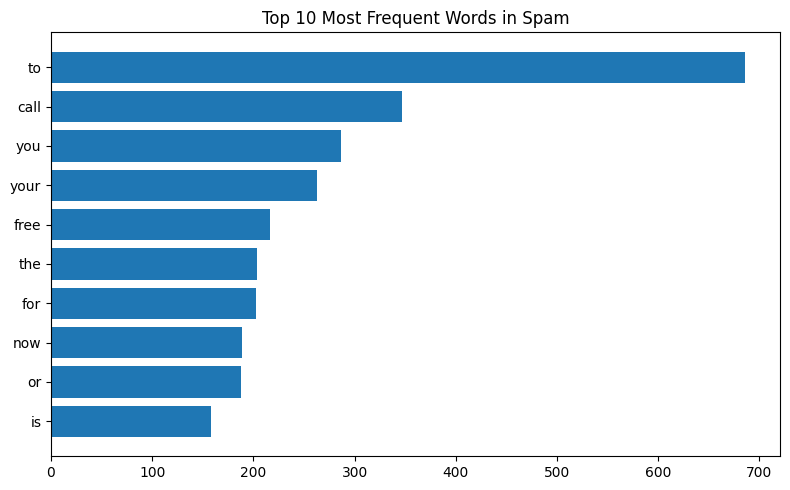

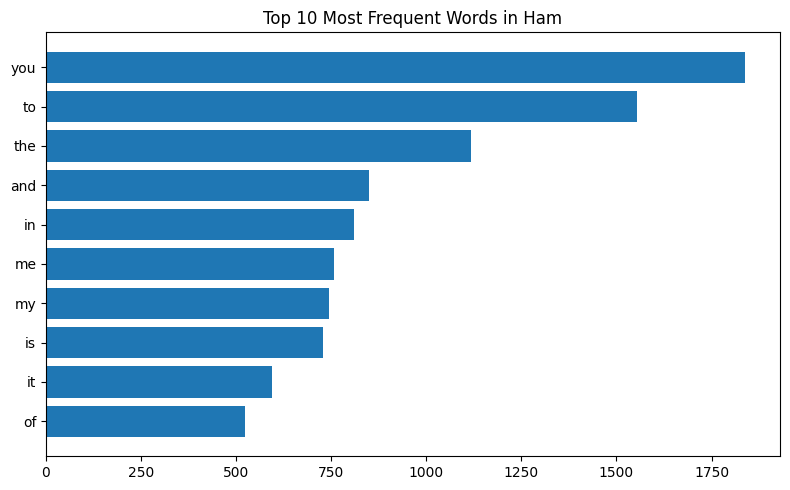

In [ ]:
#  Word Frequency Comparison (Spam vs Ham)
spam_messages = df[df['label'] == 'spam']['message']
ham_messages = df[df['label'] == 'ham']['message']

spam_vector = CountVectorizer()
ham_vector = CountVectorizer()

spam_matrix = spam_vector.fit_transform(spam_messages)
ham_matrix = ham_vector.fit_transform(ham_messages)

spam_word_counts = np.asarray(spam_matrix.sum(axis=0)).flatten()
ham_word_counts = np.asarray(ham_matrix.sum(axis=0)).flatten()

spam_words = spam_vector.get_feature_names_out()
ham_words = ham_vector.get_feature_names_out()

spam_top_idx = np.argsort(spam_word_counts)[-10:]
ham_top_idx = np.argsort(ham_word_counts)[-10:]

plt.figure(figsize=(8,5))
plt.barh(spam_words[spam_top_idx], spam_word_counts[spam_top_idx])
plt.title("Top 10 Most Frequent Words in Spam")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.barh(ham_words[ham_top_idx], ham_word_counts[ham_top_idx])
plt.title("Top 10 Most Frequent Words in Ham")
plt.tight_layout()
plt.show()

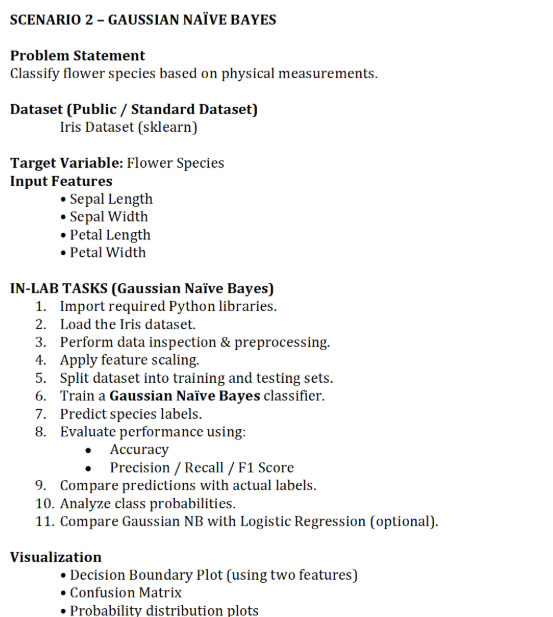

In [ ]:
#DHANESH VC 24BAD018
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [ ]:
#Load Iris Dataset
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

In [ ]:
#Convert dataset into inspection
df = pd.DataFrame(X, columns=feature_names)
df['species'] = y
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
#Data inspection
print(df.info())
print(df.describe())
print(df['species'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000

In [ ]:
#Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
#Train Gaussian Naive bayes
model = GaussianNB()
model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [ ]:
#Prediction
y_pred = model.predict(X_test)

In [ ]:
#Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


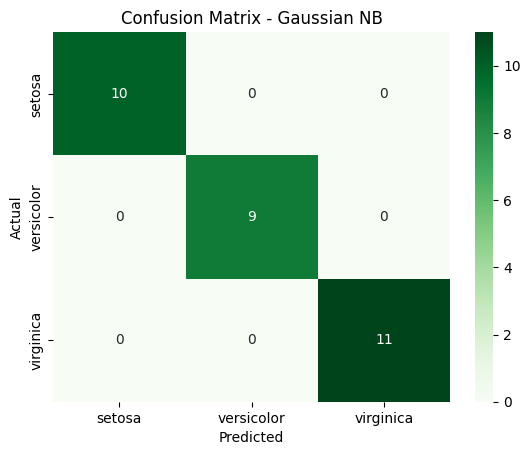

In [ ]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names,
            yticklabels=target_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Gaussian NB")
plt.show()

In [ ]:
#Decision Boundary
X2 = X_scaled[:, 2:4]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y, test_size=0.2, random_state=42
)

model2 = GaussianNB()
model2.fit(X_train2, y_train2)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [ ]:
#Probability distribution
probs = model.predict_proba(X_test)

print("Class Probabilities (First 5 samples):")
print(probs[:5])

Class Probabilities (First 5 samples):
[[5.97322611e-090 9.95635768e-001 4.36423247e-003]
 [1.00000000e+000 4.96157683e-014 6.54921950e-021]
 [7.31861098e-290 4.92947289e-012 1.00000000e+000]
 [2.81838335e-094 9.77593560e-001 2.24064404e-002]
 [1.13876385e-105 8.70022604e-001 1.29977396e-001]]


In [ ]:
#Compare predictions vs actual
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(comparison.head())

   Actual  Predicted
0       1          1
1       0          0
2       2          2
3       1          1
4       1          1


In [ ]:
#Analyse class probabilites
print("Class Priors:", model.class_prior_)

Class Priors: [0.33333333 0.34166667 0.325     ]


In [ ]:
#Compare with Logistic Regression
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 1.0


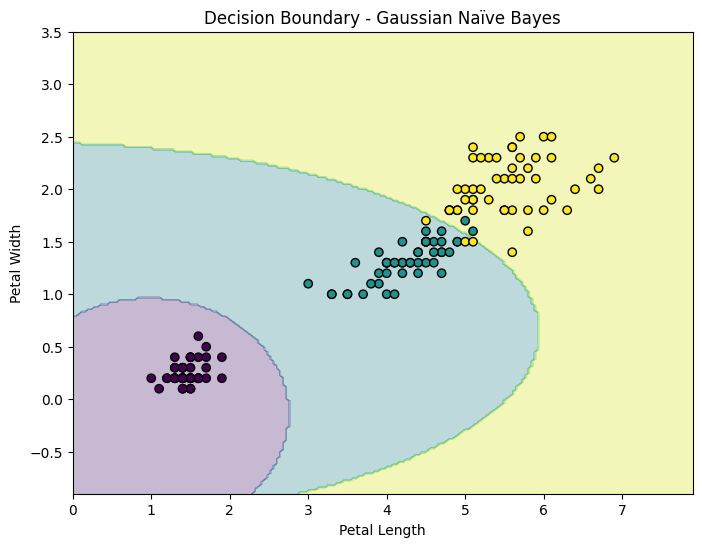

In [ ]:
iris = load_iris()
X = iris.data[:, 2:4]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = GaussianNB()
model.fit(X_train, y_train)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Decision Boundary - Gaussian Naïve Bayes")
plt.show()

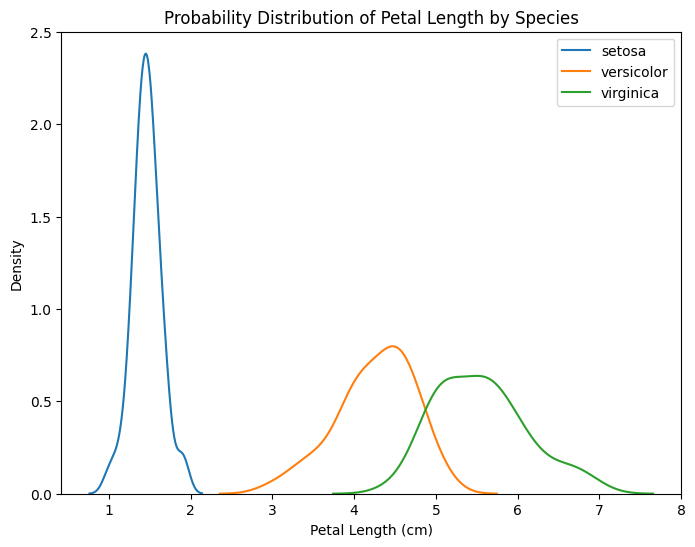

In [ ]:

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

plt.figure(figsize=(8,6))

for species in df['species'].unique():
    subset = df[df['species'] == species]
    sns.kdeplot(subset['petal length (cm)'],
                label=iris.target_names[species])

plt.xlabel("Petal Length (cm)")
plt.title("Probability Distribution of Petal Length by Species")
plt.legend()
plt.show()